# Network Anomaly Detection

## Intro

In [1]:
import requests, zipfile, io
# Download the dataset
url = "https://academy.hackthebox.com/storage/modules/292/KDD_dataset.zip"


response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))
z.extractall('.')

In [2]:
# importing the necessary libraries

# data loading handling
import numpy as np
import pandas as pd

# import algorithm used for the anomaly detection
from sklearn.ensemble import RandomForestClassifier

# dataset spliting and evaluation and validation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
# Set the file path to the dataset
file_path = r'KDD+.txt'

# Define the column names corresponding to the NSL-KDD dataset
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack', 'level'
]

In [4]:
# Read the combined NSL-KDD dataset into a DataFrame
df = pd.read_csv(file_path, names=columns)

print(df.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

## Preprocessing and Splitting the Dataset

In [5]:
# create the target: mapping normal traffic to 0 and attack to 1
df['attack_flag'] = df['attack'].apply(lambda a: 0 if a == 'normal' else 1)

In [6]:
# Creating a multi-class classification target to add granularity to the classificiation.

# Multi-class classification target categories
dos_attacks = ['apache2', 'back', 'land', 'neptune', 'mailbomb', 'pod', 
               'processtable', 'smurf', 'teardrop', 'udpstorm', 'worm']
probe_attacks = ['ipsweep', 'mscan', 'nmap', 'portsweep', 'saint', 'satan']
privilege_attacks = ['buffer_overflow', 'loadmdoule', 'perl', 'ps', 
                     'rootkit', 'sqlattack', 'xterm']
access_attacks = ['ftp_write', 'guess_passwd', 'http_tunnel', 'imap', 
                  'multihop', 'named', 'phf', 'sendmail', 'snmpgetattack', 
                  'snmpguess', 'spy', 'warezclient', 'warezmaster', 
                  'xclock', 'xsnoop']

attack_lists = [dos_attacks, probe_attacks, privilege_attacks, access_attacks]

def map_attack(attack):
    if attack in dos_attacks:
        return 1
    elif attack in probe_attacks:
        return 2
    elif attack in privilege_attacks:
        return 3
    elif attack in access_attacks:
        return 4
    else:
        return 0

df['attack_map'] = df['attack'].apply(map_attack)

In [7]:
# encoding categorical variables
features_to_encode = ['protocol_type', 'service']
encoded = pd.get_dummies(df[features_to_encode])

In [8]:
# Numeric features that capture various statistical properties of the traffic
numeric_features = [
    'duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 
    'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 
    'num_outbound_cmds', 'count', 'srv_count', 'serror_rate', 
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 
    'dst_host_srv_rerror_rate'
]

In [9]:
# combine encoded categorical valiables and numeric features
train_set = encoded.join(df[numeric_features])

# multi-class target variable
multi_y = df['attack_map']


In [10]:
# split data into training and test sets for multi-class classification
train_X, test_X, train_y, test_y = train_test_split(
    train_set,
    multi_y,
    test_size=0.2,
    random_state=1337
)

In [11]:
multi_train_X, multi_val_X, multi_train_y, multi_val_y = train_test_split(
    train_X, train_y, test_size=0.3, random_state=1337
)

## Training and Evaluation (Network Anomaly Detection)

In [12]:
# train the RandomForest model for multi-class classification
rf_model_multi = RandomForestClassifier(random_state=1337)
rf_model_multi.fit(multi_train_X, multi_train_y)

RandomForestClassifier(random_state=1337)

Validation Set Evaluation:
Accuracy: 0.9950
Precision: 0.9949
Recall: 0.9950
F1-Score: 0.9949


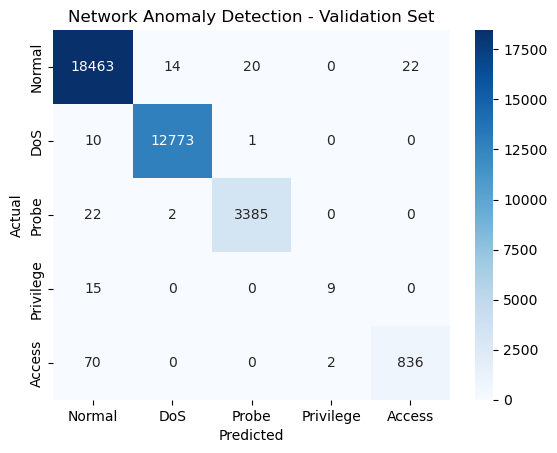

Classification Report for Validation Set:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     18519
         DoS       1.00      1.00      1.00     12784
       Probe       0.99      0.99      0.99      3409
   Privilege       0.82      0.38      0.51        24
      Access       0.97      0.92      0.95       908

    accuracy                           1.00     35644
   macro avg       0.96      0.86      0.89     35644
weighted avg       0.99      1.00      0.99     35644



In [13]:
# Predict and evaluate the model on the validation set
multi_predictions = rf_model_multi.predict(multi_val_X)
accuracy = accuracy_score(multi_val_y, multi_predictions)
precision = precision_score(multi_val_y, multi_predictions, average='weighted')
recall = recall_score(multi_val_y, multi_predictions, average='weighted')
f1 = f1_score(multi_val_y, multi_predictions, average='weighted')
print(f"Validation Set Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix for Validation Set
conf_matrix = confusion_matrix(multi_val_y, multi_predictions)
class_labels = ['Normal', 'DoS', 'Probe', 'Privilege', 'Access']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Network Anomaly Detection - Validation Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Validation Set
print("Classification Report for Validation Set:")
print(classification_report(multi_val_y, multi_predictions, target_names=class_labels))

In [14]:
# saving the model
import joblib

model_filename = 'network_anomaly_detection_model.joblib'
joblib.dump(rf_model_multi, model_filename)
print(f"Model saved to {model_filename}")

Model saved to network_anomaly_detection_model.joblib
